In [16]:
from pypot.dynamixel import DxlIO
from pypot.dynamixel.protocol.v1 import *

from glob import glob

ports = glob('/dev/ttyACM*')
assert len(ports) == 1

port = ports[0]
print('Connecting on port: {}'.format(port))
dxl_io = DxlIO(port)

poulpe_id = 42
N_AXIS = 2

Connecting on port: /dev/ttyACM0


In [2]:
ping_packet = DxlPingPacket(poulpe_id)
dxl_io._send_packet(ping_packet)

DxlStatusPacket(id=42, error=0, parameters=())

In [3]:
import struct

def read_current_pos():
    pos_packet = DxlReadDataPacket(poulpe_id, 50, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_current_pos()

(0.0, 0.0)

In [4]:
import struct

def read_target_position():
    pos_packet = DxlReadDataPacket(poulpe_id, 60, N_AXIS * 4)
    resp = dxl_io._send_packet(pos_packet,wait_for_status_packet=True)
    data = bytearray(resp.parameters)
    pos = struct.unpack(N_AXIS * 'f', data)
    return pos

read_target_position()

(0.0, 0.0)

In [5]:
def write_target_position(target):
    p = DxlWriteDataPacket(poulpe_id, 60, struct.pack(N_AXIS * 'f', *target))
    resp = dxl_io._send_packet(p,wait_for_status_packet=True)
    return resp

write_target_position([0.5, 0.5])

DxlStatusPacket(id=42, error=0, parameters=())

In [17]:
def read_torque_enabled():
    p = DxlReadDataPacket(poulpe_id, 40, N_AXIS)
    resp = dxl_io._send_packet(p)
    data = bytearray(resp.parameters)
    torque = struct.unpack(N_AXIS * '?', data)
    return torque

read_torque_enabled()

(True, True)

In [7]:
def write_torque_enabled(torque):
    p = DxlWriteDataPacket(poulpe_id, 40, struct.pack(N_AXIS * '?', *torque))
    resp = dxl_io._send_packet(p)
    return resp

write_torque_enabled([False, False])

DxlStatusPacket(id=42, error=0, parameters=())

In [8]:
write_torque_enabled([True, True])

DxlStatusPacket(id=42, error=0, parameters=())

In [45]:
import time
import numpy as np

pos = []
send_target = []
read_target = []


t0 = time.time()
freq=1.0
cur=read_current_pos()
while True:
    if time.time() - t0 > 5:
        break

    target = [
        60 * np.sin(2 * np.pi * freq * (time.time()-t0)), 
        60 * np.sin(2 * np.pi * freq * (time.time()-t0)),
    ]
    write_target_position(target)
    
    send_target.append(target)
    time.sleep(0.001)
    cur=read_current_pos()
    pos.append(cur)
    read_target.append(cur)
    time.sleep(0.001)

In [26]:
np.array(send_target) - np.array(pos)

array([[ 1.2773433 ,  1.31537913],
       [ 2.06730796,  2.07233794],
       [ 2.66341394,  2.76178308],
       ...,
       [10.10804953, 10.20345858],
       [10.24853833, 10.2818539 ],
       [10.32015554, 10.41547831]])

In [13]:
write_torque_enabled([False, False])

DxlStatusPacket(id=42, error=0, parameters=())

In [27]:
np.array(send_target)

array([[ 0.2460933 ,  0.25287913],
       [ 1.09855796,  1.10358794],
       [ 1.94466394,  1.94928308],
       ...,
       [-2.01695047, -2.01529142],
       [-1.22021167, -1.2181461 ],
       [-0.42984446, -0.42827169]])

In [29]:
np.array(pos)

array([[ -1.03125,  -1.0625 ],
       [ -0.96875,  -0.96875],
       [ -0.71875,  -0.8125 ],
       ...,
       [-12.125  , -12.21875],
       [-11.46875, -11.5    ],
       [-10.75   , -10.84375]])

In [36]:
write_target_position([10.0,10.0])

DxlStatusPacket(id=42, error=0, parameters=())

In [37]:
read_target_position()

(10.0, 10.0)

In [39]:
read_current_pos()

(10.0, 10.0)

In [40]:
import matplotlib.pyplot as plt

In [41]:
%matplotlib inline

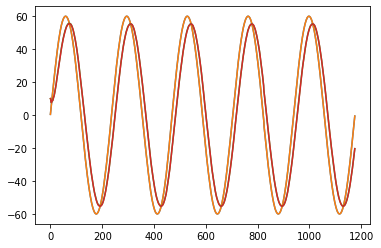

In [46]:
plt.plot(send_target)
plt.plot(pos)